In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [323]:
def forcing_1(x):
    return 1

In [324]:
import numpy as np

def forcing_matrix(element_length, source_function, wavelet_scale):
    """
    Create the forcing matrix for a 1D multi-scale finite element.
    
    Parameters:
        element_length (float): Length of the physical element.
        source_function (callable): Source function f(x) to integrate.
        wavelet_scale (int): Number of hierarchical levels.
    
    Returns:
        F (numpy array): Forcing vector for the given element.
    """
    total_nodes = 2 + sum(2**l for l in range(wavelet_scale))
    F = np.zeros(total_nodes)
    
    # Jacobian of the transformation
    J = element_length / 2
    
    # Basis function definitions
    def phi_coarse(i, xi):
        """Coarse-scale basis functions."""
        if i == 0:
            return (1 - xi) / 2
        elif i == 1:
            return (1 + xi) / 2
        else:
            raise ValueError("Invalid coarse basis index")

    def phi_fine(l, j, xi):
        """Fine-scale pseudo-wavelet basis functions."""
        # l: level, j: index within the level
        # Define the support for the basis function
        left = -1 + j * (2 / (2**l))
        right = -1 + (j + 1) * (2 / (2**l))
        midpoint = (left + right) / 2
        
        if left <= xi < midpoint:
            return (xi - left) / (midpoint - left)
        elif midpoint <= xi <= right:
            return (right - xi) / (right - midpoint)
        else:
            return 0

    # Coarse-scale contributions (nodes 0 and 1)
    for i in range(2):  # Loop over coarse nodes
        F[i] = J * integrate_analytically(lambda xi: source_function(xi) * phi_coarse(i, xi))

    # Fine-scale contributions
    node_index = 2  # Starting node index for fine-scale functions
    for l in range(wavelet_scale):
        for j in range(2**l):
            F[node_index] = J * integrate_analytically(lambda xi: source_function(xi) * phi_fine(l, j, xi))
            node_index += 1
    F = F.reshape((total_nodes,1))

    return F

def integrate_analytically(func):
    """
    Perform integration using 3-point Gauss-Legendre quadrature.
    """
    # Gauss-Legendre quadrature points and weights for 3-point rule
    pts = [-np.sqrt(3 / 5), 0, np.sqrt(3 / 5)]
    weights = [5 / 9, 8 / 9, 5 / 9]
    
    # Perform integration
    integral = sum(w * func(pt) for pt, w in zip(pts, weights))
    return integral

# def integrate_analytically(func):
#     """
#     Perform integration analytically if the function is simple, else approximate numerically.
#     """
#     # Numerical integration (can replace with analytical integration if needed)
#     from scipy.integrate import quad
#     result, _ = quad(func, -1, 1)
#     return result

# Example usage
element_length = 1.0  # Physical element length
wavelet_scale = 2  # Number of hierarchical levels

# Source function: f(x) = 1
source_function = lambda xi: 1

F_element = forcing_matrix(element_length, source_function, wavelet_scale)
print("Forcing matrix for the element:")
print(F_element)


Forcing matrix for the element:
[[0.5       ]
 [0.5       ]
 [0.56966852]
 [0.12522407]
 [0.12522407]]


In [325]:
import numpy as np

def mass_matrix(element_length, wavelet_scale):
    """
    Create the mass matrix for a 1D multi-scale finite element.
    
    Parameters:
        element_length (float): Length of the physical element.
        wavelet_scale (int): Number of hierarchical levels.
    
    Returns:
        M (numpy array): Mass matrix for the given element.
    """
    total_nodes = 2 + sum(2**l for l in range(wavelet_scale))  # Total number of nodes
    M = np.zeros((total_nodes, total_nodes))  # Initialize mass matrix
    
    # Jacobian of the transformation
    J = element_length / 2  # Mapping from [-1, 1] to physical element
    
    # Define basis functions
    def phi_coarse(i, xi):
        """Coarse-scale basis functions."""
        if i == 0:
            return (1 - xi) / 2
        elif i == 1:
            return (1 + xi) / 2
        else:
            raise ValueError("Invalid coarse basis index")

    def phi_fine(l, j, xi):
        """Fine-scale pseudo-wavelet basis functions."""
        # l: level, j: index within the level
        # Define the support for the basis function
        left = -1 + j * (2 / (2**l))
        right = -1 + (j + 1) * (2 / (2**l))
        midpoint = (left + right) / 2
        
        if left <= xi < midpoint:
            return (xi - left) / (midpoint - left)
        elif midpoint <= xi <= right:
            return (right - xi) / (right - midpoint)
        else:
            return 0

    # Gauss-Legendre quadrature points and weights for 3-point rule
    pts = [-np.sqrt(3 / 5), 0, np.sqrt(3 / 5)]
    weights = [5 / 9, 8 / 9, 5 / 9]
    
    def integrate(func1, func2):
        """
        Perform integration using Gauss-Legendre quadrature for func1 * func2 over [-1, 1].
        """
        return J * sum(w * func1(xi) * func2(xi) for xi, w in zip(pts, weights))
    
    # Coarse-scale contributions (nodes 0 and 1)
    M[0:2, 0:2] = np.array([
        [integrate(lambda xi: phi_coarse(0, xi), lambda xi: phi_coarse(0, xi)),
         integrate(lambda xi: phi_coarse(0, xi), lambda xi: phi_coarse(1, xi))],
        [integrate(lambda xi: phi_coarse(1, xi), lambda xi: phi_coarse(0, xi)),
         integrate(lambda xi: phi_coarse(1, xi), lambda xi: phi_coarse(1, xi))]
    ])
    
    # Fine-scale contributions
    node_index = 2  # Starting node index for fine-scale functions
    for l in range(wavelet_scale):
        for j in range(2**l):
            fine_index = node_index
            for coarse_index in range(2):
                # Interaction between fine and coarse basis functions
                M[coarse_index][fine_index] = integrate(
                    lambda xi: phi_coarse(coarse_index, xi),
                    lambda xi: phi_fine(l, j, xi)
                )
                M[fine_index][coarse_index] = M[coarse_index][fine_index]
            
            # Self-contribution for fine basis functions
            M[fine_index][fine_index] = integrate(
                lambda xi: phi_fine(l, j, xi),
                lambda xi: phi_fine(l, j, xi)
            )
            
            node_index += 1

    # Populate diagonal entries for higher levels and adjust interactions
    diagonal_ele = 4 / 3
    for i in range(2, total_nodes):
        cur_level_i = np.ceil(np.log2(i))  # Current hierarchical level of node i
        M[i][i] = diagonal_ele / (2**cur_level_i)  # Diagonal contribution
    
    return M


# Example usage
element_length = 1.0  # Physical element length
wavelet_scale = 2  # Number of hierarchical levels

M_element = mass_matrix(element_length, wavelet_scale)
print("Mass matrix for the element:")
print(M_element)

Mass matrix for the element:
[[0.33333333 0.16666667 0.28483426 0.11111111 0.01411296]
 [0.16666667 0.33333333 0.28483426 0.01411296 0.11111111]
 [0.28483426 0.28483426 0.66666667 0.         0.        ]
 [0.11111111 0.01411296 0.         0.33333333 0.        ]
 [0.01411296 0.11111111 0.         0.         0.33333333]]


In [583]:
def phi_coarse(i, xi):
    """
    Coarse-scale basis functions.
    
    Parameters:
        i (int): Index of the coarse basis function (0 or 1).
        xi (float): Point in the reference element [-1, 1].

    Returns:
        float: Value of the basis function at xi.
    """
    if i == 0:
        return (1 - xi) / 2
    elif i == 1:
        return (1 + xi) / 2
    else:
        raise ValueError("Invalid coarse basis index")

def phi_fine(l, j, xi):
    """
    Fine-scale pseudo-wavelet basis functions.

    Parameters:
        l (int): Level of the wavelet basis.
        j (int): Index within the level.
        xi (float): Point in the reference element [-1, 1].

    Returns:
        float: Value of the basis function at xi.
    """
    # Define the support for the basis function
    left = -1 + j * (2 / (2**l))
    right = -1 + (j + 1) * (2 / (2**l))
    midpoint = (left + right) / 2

    if left <= xi < midpoint:
        return (xi - left) / (midpoint - left)
    elif midpoint <= xi <= right:
        return (right - xi) / (right - midpoint)
    else:
        return 0

def interpolate_solution(C_wavelet, total_nodes, x_ini, x_final, wavelet_scale, x_values):
    """
    Compute the interpolated solution given the wavelet coefficients.

    Parameters:
        C_wavelet (numpy.ndarray): Wavelet coefficients.
        element_length (float): Length of the physical element.
        wavelet_scale (int): Number of hierarchical levels.
        x_values (numpy.ndarray): Points in the physical domain for interpolation.

    Returns:
        numpy.ndarray: Interpolated solution at the given x-coordinates.
    """
    # Total number of nodes
    wavelet_nodes = 2 + sum(2**l for l in range(wavelet_scale))
    num_nodes = 2**(wavelet_scale)
    element_length = (x_final - x_ini)/(total_nodes - 1)
    
    # Map physical coordinates to reference element [-1, 1]
    def map_to_reference(x, x1, x2):
        
        return ((2*x - (x1 + x2)) / element_length) 

    # Initialize the interpolated solution
    interpolated_solution = np.zeros_like(x_values)

    # Loop through all x values to calculate the interpolated solution
    count = 0 
    while count < total_nodes-1:
        # x_element = x_values[count*(wavelet_nodes - 1) : (count+1)*(wavelet_nodes - 1) + 1]
        # print(x_element.shape)
        for i in range(count*(num_nodes), (count+1)*(num_nodes)):
            x1 = count*element_length
            x2 = (count+1)*element_length
            # print(x_element.shape, i)
            xi = map_to_reference(x_values[i],x1,x2)  # Map to reference element
            

            # Add contributions from coarse-scale basis functions
            phi_si_val = np.zeros((wavelet_nodes,1))
            phi_si_val[0] = phi_coarse(0, xi)
            phi_si_val[1] = phi_coarse(1, xi)
            
            # interpolated_solution[i] += C_wavelet[i] * phi_coarse(0, xi)
            # interpolated_solution[i] += C_wavelet[i] * phi_coarse(1, xi)
            

            # Add contributions from fine-scale basis functions
            node_index = 2
            for l in range(wavelet_scale):
                for j in range(2**l):
                    phi_si_val[node_index] = phi_fine(l, j, xi)
                    # interpolated_solution[i] += C_wavelet[node_index] * phi_fine(l, j, xi)
                    node_index += 1
                    
            if interpolated_solution[i] == 0:
                interpolated_solution[i] = phi_si_val.T @ C_wavelet[count*(wavelet_nodes) : (count+1)*(wavelet_nodes)]
                
            # print(xi, phi_si_val)
                
        count+=1

    return interpolated_solution

In [327]:
def static_solution_fea(total_nodes, K, M, f, bc1, bc2):

    boundary = [0, total_nodes -1]
    n = total_nodes
    C = np.zeros((n,1))
    C[boundary[0]] = bc1
    C[boundary[1]] = bc2
    unknown_indices = np.setdiff1d(np.arange(n), boundary)

    # Extract submatrix K_uu (rows and columns corresponding to unknowns)
    K_uu = K[np.ix_(unknown_indices, unknown_indices)]
    M_uu = M[np.ix_(unknown_indices, unknown_indices)]
    K_uu_2 = K[np.ix_(unknown_indices, boundary)]
    M_uu_2 = M[np.ix_(unknown_indices, boundary)]
    rhs = f[unknown_indices] - ((K_uu_2+ M_uu_2) @ C[boundary])
    C_uu = np.linalg.inv(K_uu + M_uu) @ rhs

    # Place the solved values back into the original C array at the correct indices
    C[unknown_indices] = C_uu
    
    return C

In [328]:
def static_solution_wavelet(total_nodes, K, M, f, bc1, bc2):

    boundary = [0, 1]
    n = total_nodes
    C = np.zeros((n,1))
    C[boundary[0]] = bc1
    C[boundary[1]] = bc2
    unknown_indices = np.setdiff1d(np.arange(n), boundary)

    # Extract submatrix K_uu (rows and columns corresponding to unknowns)
    K_uu = K[np.ix_(unknown_indices, unknown_indices)]
    M_uu = M[np.ix_(unknown_indices, unknown_indices)]
    K_uu_2 = K[np.ix_(unknown_indices, boundary)]
    M_uu_2 = M[np.ix_(unknown_indices, boundary)]
    rhs = f[unknown_indices] - ((K_uu_2+ M_uu_2) @ C[boundary])
    C_uu = np.linalg.inv(K_uu + M_uu) @ rhs

    # Place the solved values back into the original C array at the correct indices
    C[unknown_indices] = C_uu
    
    return C

In [329]:
def calculate_k(wavelet_scale):
    total_nodes = 2 + sum(2**l for l in range(wavelet_scale))  # Total number of nodes
    K = np.zeros((total_nodes, total_nodes))  # Initialize mass matrix
    K[0:2,0:2] = np.array([[1, -1], [-1, 1]])
    
    j = 2
    count = 0
    while count < wavelet_scale:
        for i in range(2**count):
            K[j,j] = 2**(count+2)
            j+=1
        count+=1

    return K        

element_length = 1
wavelet_scale = 2
K = calculate_k(wavelet_scale)
print(K)

[[ 1. -1.  0.  0.  0.]
 [-1.  1.  0.  0.  0.]
 [ 0.  0.  4.  0.  0.]
 [ 0.  0.  0.  8.  0.]
 [ 0.  0.  0.  0.  8.]]


In [330]:
C = static_solution_fea(K.shape[0], K,M_element, F_element, 0,0)

In [331]:
C

array([[0.        ],
       [0.35337723],
       [0.10050312],
       [0.01442842],
       [0.        ]])

In [443]:
def construct_bilinear(total_nodes, x_ini, x_final):
    
    n = total_nodes
    K_full = np.zeros((n,n))
    # A_y = np.zeros((n,n))
    ele_size = (x_final - x_ini)/(n-1)
    
    for i in range(n-1):
        # nodes = node_tags[i]
        x1 = x_ini + i*(ele_size)
        x2 = x_ini + (i+1)*ele_size
        jac = (x2 - x1)/2
        pts = [-np.sqrt(3 / 5), 0, np.sqrt(3 / 5)]
        weights = [5 / 9, 8 / 9, 5 / 9]
        
        a_x = np.zeros((2,2))
        dphi =  (1/jac)*np.array([[-1/2],[1/2]])
        for j in range(len(weights)):
            # N_x = np.array([-1, 1, 0]) * (1/(x2-x1)) + np.array([-1, 0, 1])*(1/(x3-x1))
            # N_y = np.array([-1, 1, 0]) * (1/(y2-y1)) + np.array([-1, 0, 1])*(1/(y3-y1))
            x = x1*(1-pts[j])/2 + x2*(1+pts[j])/2 
            # N_x = dphi[0,:]
            # N_y = dphi[1,:]
            # N_x = N_x.reshape((3, 1))
            # N_y = N_y.reshape((3, 1))
            a_x += (dphi @ dphi.T)*jac*weights[j]
            # a_y += (N_y @ N_y.T)*jac*weights[j]*kappa
        
        # for k in range(3):
        #     for l in range(3):
        #         A_x[int(nodes[k]-1), int(nodes[l]-1)] += a_x[k][l]
        #         A_y[int(nodes[k]-1), int(nodes[l]-1)] += a_y[k][l]
                    
        # A_2d[0,0] += (numerical_intergation(neg_func, xi, xi_1)*jac)
        # A_2d[0,1] += (numerical_intergation(prod_func, xi, xi_1)*jac)
        # A_2d[1,0] += (numerical_intergation(prod_func, xi, xi_1)*jac)
        # A_2d[1,1] += (numerical_intergation(pos_func, xi, xi_1)*jac)
        
        K_full[i:i+2, i:i+2] += a_x
        
    return K_full

In [444]:
K_full = construct_bilinear(10,0,1)

In [445]:
K_full

array([[ 9., -9.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [-9., 18., -9.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -9., 18., -9.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -9., 18., -9.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -9., 18., -9.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -9., 18., -9.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -9., 18., -9.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -9., 18., -9.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -9., 18., -9.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -9.,  9.]])

In [446]:
def construct_forcing(forcing_func,total_nodes, x_ini, x_final):
    
    n = total_nodes
    F_full = np.zeros((n,1))
    # A_y = np.zeros((n,n))
    ele_size = (x_final - x_ini)/(n-1)
    
    for i in range(n-1):
        # nodes = node_tags[i]
        x1 = x_ini + i*(ele_size)
        x2 = x_ini + (i+1)*ele_size
        jac = (x2 - x1)/2
        pts = [-np.sqrt(3 / 5), 0, np.sqrt(3 / 5)]
        weights = [5 / 9, 8 / 9, 5 / 9]
        
        f_x = np.zeros((2,1))
        # dphi =  (1/jac)*np.array([[-1/2],[1/2]])
        for j in range(len(weights)):
            # N_x = np.array([-1, 1, 0]) * (1/(x2-x1)) + np.array([-1, 0, 1])*(1/(x3-x1))
            # N_y = np.array([-1, 1, 0]) * (1/(y2-y1)) + np.array([-1, 0, 1])*(1/(y3-y1))
            x = x1*(1-pts[j])/2 + x2*(1+pts[j])/2 
            f_x[0,0] += ((1-pts[j])/2) * forcing_func(x) * weights[j] * jac
            f_x[1,0] += ((1+pts[j])/2) * forcing_func(x) * weights[j] * jac
            # N_x = dphi[0,:]
            # N_y = dphi[1,:]
            # N_x = N_x.reshape((3, 1))
            # N_y = N_y.reshape((3, 1))
            # a_x += (dphi @ dphi.T)*jac*weights[j]
            # a_y += (N_y @ N_y.T)*jac*weights[j]*kappa
        
        # for k in range(3):
        #     for l in range(3):
        #         A_x[int(nodes[k]-1), int(nodes[l]-1)] += a_x[k][l]
        #         A_y[int(nodes[k]-1), int(nodes[l]-1)] += a_y[k][l]
                    
        # A_2d[0,0] += (numerical_intergation(neg_func, xi, xi_1)*jac)
        # A_2d[0,1] += (numerical_intergation(prod_func, xi, xi_1)*jac)
        # A_2d[1,0] += (numerical_intergation(prod_func, xi, xi_1)*jac)
        # A_2d[1,1] += (numerical_intergation(pos_func, xi, xi_1)*jac)
        
        F_full[i:i+2] += f_x
        
    return F_full

In [447]:
F_full = construct_forcing(forcing_1,10,0,1)

In [448]:
F_full

array([[0.05555556],
       [0.11111111],
       [0.11111111],
       [0.11111111],
       [0.11111111],
       [0.11111111],
       [0.11111111],
       [0.11111111],
       [0.11111111],
       [0.05555556]])

In [449]:
def construct_mass(total_nodes, x_ini, x_final):
    
    n = total_nodes
    M_full = np.zeros((n,n))
    # A_y = np.zeros((n,n))
    ele_size = (x_final - x_ini)/(n-1)
    
    for i in range(n-1):
        # nodes = node_tags[i]
        x1 = x_ini + i*(ele_size)
        x2 = x_ini + (i+1)*ele_size
        jac = (x2 - x1)/2
        pts = [-np.sqrt(3 / 5), 0, np.sqrt(3 / 5)]
        weights = [5 / 9, 8 / 9, 5 / 9]
        
        m_x = np.zeros((2,2))
        dphi =  (1/jac)*np.array([[-1/2],[1/2]])
        for j in range(len(weights)):
            # N_x = np.array([-1, 1, 0]) * (1/(x2-x1)) + np.array([-1, 0, 1])*(1/(x3-x1))
            # N_y = np.array([-1, 1, 0]) * (1/(y2-y1)) + np.array([-1, 0, 1])*(1/(y3-y1))
            x = x1*(1-pts[j])/2 + x2*(1+pts[j])/2 
            m_x += np.array([[((1-pts[j])/2)**2, ((1+pts[j])*(1-pts[j])/4)], [((1+pts[j])*(1-pts[j])/4), ((1+pts[j])/2)**2]])*jac*weights[j]
            # N_x = dphi[0,:]
            # N_y = dphi[1,:]
            # N_x = N_x.reshape((3, 1))
            # N_y = N_y.reshape((3, 1))
            # a_x += (dphi @ dphi.T)
            # a_y += (N_y @ N_y.T)*jac*weights[j]*kappa
        
        # for k in range(3):
        #     for l in range(3):
        #         A_x[int(nodes[k]-1), int(nodes[l]-1)] += a_x[k][l]
        #         A_y[int(nodes[k]-1), int(nodes[l]-1)] += a_y[k][l]
                    
        # A_2d[0,0] += (numerical_intergation(neg_func, xi, xi_1)*jac)
        # A_2d[0,1] += (numerical_intergation(prod_func, xi, xi_1)*jac)
        # A_2d[1,0] += (numerical_intergation(prod_func, xi, xi_1)*jac)
        # A_2d[1,1] += (numerical_intergation(pos_func, xi, xi_1)*jac)
        
        M_full[i:i+2, i:i+2] += m_x
        
    return M_full

In [450]:
M_full = construct_mass(10, 0, 1)

In [451]:
M_full

array([[0.03703704, 0.01851852, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.01851852, 0.07407407, 0.01851852, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.01851852, 0.07407407, 0.01851852, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.01851852, 0.07407407, 0.01851852,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.01851852, 0.07407407,
        0.01851852, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.01851852,
        0.07407407, 0.01851852, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.01851852, 0.07407407, 0.01851852, 0.        , 0.        ],
       [0.        , 0.        , 0.       

MAIN CODE

In [584]:
eps = 1
gamma = 0
x_ini = 0
x_final = 1
total_nodes = 3
bc1 = 0
bc2 = 0
element_length = (x_final-x_ini)/(total_nodes-1)

In [585]:
K_fea = construct_bilinear(total_nodes, x_ini, x_final) * eps
M_fea = construct_mass(total_nodes, x_ini, x_final) * gamma
f_fea = construct_forcing(forcing_1, total_nodes, x_ini, x_final)

In [586]:
C_fea = static_solution_fea(total_nodes, K_fea, M_fea, f_fea, bc1, bc2)

In [587]:
x_array = np.linspace(x_ini, x_final, total_nodes)

In [588]:
C_fea

array([[0.   ],
       [0.125],
       [0.   ]])

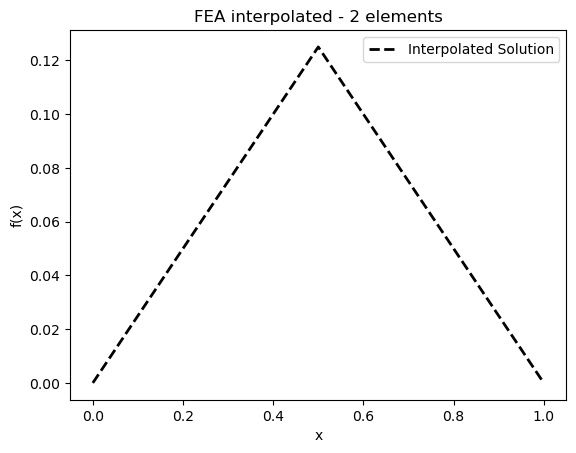

In [589]:
# Plot the actual solution with a solid blue line
plt.plot(x_array, C_fea, color='black', linestyle='--', label='Interpolated Solution', linewidth=2, zorder=2)

# # Plot the interpolated solution with a dashed red line and circle markers
# plt.plot(x_array, sol, linestyle='--', color='r', marker='o', label='Actual Solution', 
#          linewidth=2, markersize=4, zorder=1, alpha=0.6)

# Add labels to the axes
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title("FEA interpolated - 2 elements")
# Add a legend to distinguish the two plots
plt.legend(loc='best')

# Show the plot
plt.show()

**Wavelet implementation**

For Wavelet Scale = 1

In [590]:
wavelet_scale = 1
C_wavelet_1 = np.zeros(((2**wavelet_scale + 1)* (total_nodes-1) , 1))
x_array_wavelet_1 = np.linspace(x_ini, x_final, (2**(wavelet_scale)) * (total_nodes - 1) + 1)

In [591]:
for i in range(total_nodes-1):
    k_wavelet_1 = calculate_k(wavelet_scale) * (eps/element_length)    
    f_wavelet_1 = forcing_matrix(element_length, forcing_1, wavelet_scale)
    m_wavelet_1 = mass_matrix(element_length, wavelet_scale) * gamma
    bc1 = C_fea[i]
    bc2 = C_fea[i+1]
    C_element = static_solution_wavelet(2**wavelet_scale +1, k_wavelet_1, m_wavelet_1, f_wavelet_1, bc1, bc2)
    C_wavelet_1[i*(2**wavelet_scale + 1): (i+1)*(2**wavelet_scale +1)] = C_element

In [592]:
C_wavelet_1

array([[0.        ],
       [0.125     ],
       [0.03560428],
       [0.125     ],
       [0.        ],
       [0.03560428]])

In [593]:
C_wavelet_1.shape, x_array_wavelet_1.shape

((6, 1), (5,))

In [594]:
x_array_wavelet_1

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [595]:
inter_sol_1 = interpolate_solution(C_wavelet_1, total_nodes, x_ini, x_final, wavelet_scale, x_array_wavelet_1)

In [596]:
inter_sol_1.shape

(5,)

In [597]:
inter_sol_1

array([0.        , 0.09810428, 0.125     , 0.09810428, 0.        ])

For Wavelet Scale = 2

In [598]:
wavelet_scale = 2
C_wavelet_2 = np.zeros(((2**wavelet_scale + 1)* (total_nodes-1) , 1))
x_array_wavelet_2 = np.linspace(x_ini, x_final, (2**(wavelet_scale)) * (total_nodes - 1) + 1)

In [599]:
for i in range(total_nodes-1):
    k_wavelet_2 = calculate_k(wavelet_scale) * (eps/element_length)    
    f_wavelet_2 = forcing_matrix(element_length, forcing_1, wavelet_scale)
    m_wavelet_2 = mass_matrix(element_length, wavelet_scale) * gamma
    bc1 = C_fea[i]
    bc2 = C_fea[i+1]
    C_element = static_solution_wavelet(2**wavelet_scale +1, k_wavelet_2, m_wavelet_2, f_wavelet_2, bc1, bc2)
    C_wavelet_2[i*(2**wavelet_scale + 1): (i+1)*(2**wavelet_scale +1)] = C_element

In [600]:
inter_sol_2 = interpolate_solution(C_wavelet_2, total_nodes, x_ini, x_final, wavelet_scale, x_array_wavelet_2)

Exact Solution

In [605]:
def exact_sol(x):
    return (x - x**2)/2

In [606]:
x_100 = np.linspace(x_ini, x_final, 100)
exact_array = exact_sol(x_100)

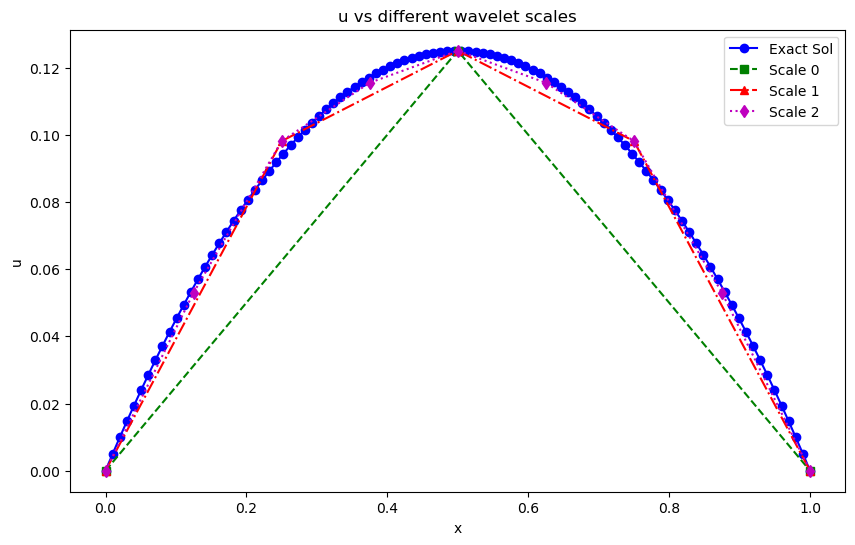

In [610]:
# Combine data for iteration
x_arrays = [x_100, x_array, x_array_wavelet_1, x_array_wavelet_2]
solution_arrays = [exact_array, C_fea, inter_sol_1, inter_sol_2]
labels = ["Exact Sol", "Scale 0", "Scale 1", "Scale 2"]

# Custom styles
line_styles = ['-', '--', '-.', ':']
colors = ['b', 'g', 'r', 'm']
markers = ['o', 's', '^', 'd']  # Unique markers

# Plot
plt.figure(figsize=(10, 6))
for i in range(4):
    plt.plot(x_arrays[i], solution_arrays[i],
             linestyle=line_styles[i], 
             color=colors[i], 
             marker=markers[i], 
             label=labels[i])

# Add labels, legend, and grid
plt.xlabel("x")
plt.ylabel("u")
plt.title("u vs different wavelet scales")
plt.legend()
# plt.grid(True)
plt.show()

**CONVERGENCE TEST**

(3, 1)
(3, 1)
(5, 1)
(5, 1)
(9, 1)
(9, 1)
(17, 1)
(17, 1)
0.1075 0.1


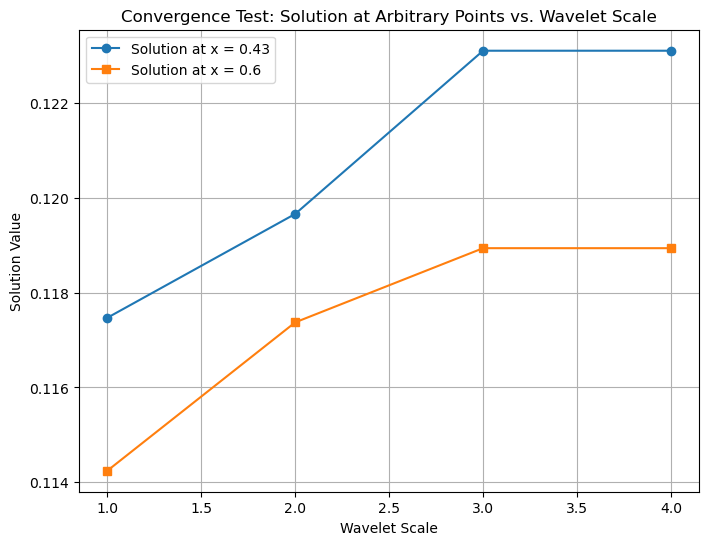

In [913]:
# Arbitrary points to evaluate
x_point1 = 0.43
x_point2 = 0.60
points = [x_point1, x_point2]

# Domain and parameters
x_ini, x_final = 0, 1
total_nodes = 3  # Example: number of nodes in the domain
element_length = (x_final - x_ini) / (total_nodes - 1)
x_array_wavelet = np.linspace(x_ini, x_final, total_nodes * 10)  # Dense points for visualization

# Boundary conditions
bc1, bc2 = 0, 0
# forcing_1 = lambda x: 1
eps = 1  # Diffusion coefficient
gamma = 0  # Mass coefficient

K_fea = construct_bilinear(total_nodes, x_ini, x_final) * eps
M_fea = construct_mass(total_nodes, x_ini, x_final) * gamma
f_fea = construct_forcing(forcing_1, total_nodes, x_ini, x_final)
C_fea = static_solution_fea(total_nodes, K_fea, M_fea, f_fea, bc1, bc2)
x_array = np.linspace(x_ini, x_final, total_nodes)

# To store results for different scales
solution_values_point1 = []
solution_values_point2 = []

# Perform convergence test
for wavelet_scale in range(1,5):  # Scales from 0 to 4  # Initialize coefficients
    C_wavelet = np.zeros(((2**wavelet_scale + 1)* (total_nodes-1) , 1))
    x_array_wavelet = np.linspace(x_ini, x_final, (2**(wavelet_scale)) * (total_nodes - 1) + 1)

        
    for i in range(total_nodes-1):
        k_wavelet = calculate_k(wavelet_scale) * (eps/element_length)    
        f_wavelet = forcing_matrix(element_length, forcing_1, wavelet_scale)
        m_wavelet = mass_matrix(element_length, wavelet_scale) * gamma
        bc1_local = C_fea[i]
        bc2_local = C_fea[i+1]
        C_element = static_solution_wavelet(2**wavelet_scale +1, k_wavelet, m_wavelet, f_wavelet, bc1_local, bc2_local)
        print(C_element.shape)
        C_wavelet[i*(2**wavelet_scale + 1): (i+1)*(2**wavelet_scale +1)] = C_element

    # Interpolate the solution
    interpolated_solution = interpolate_solution(C_wavelet, total_nodes, x_ini, x_final, wavelet_scale, x_array_wavelet)

    # Find values at arbitrary points
    solution_at_point1 = np.interp(x_point1, x_array_wavelet, interpolated_solution.flatten())
    solution_at_point2 = np.interp(x_point2, x_array_wavelet, interpolated_solution.flatten())
    fea_at_point1 = np.interp(x_point1, x_array, C_fea.flatten())
    fea_at_point2 = np.interp(x_point2, x_array, C_fea.flatten())
    

    # Store results
    solution_values_point1.append(solution_at_point1)
    solution_values_point2.append(solution_at_point2)

# Plot the convergence results
wavelet_levels = [1,2,3,4]  # Levels from 0 to 4
plt.figure(figsize=(8, 6))
plt.plot(wavelet_levels, solution_values_point1, marker='o', label=f"Solution at x = {x_point1}")
plt.plot(wavelet_levels, solution_values_point2, marker='s', label=f"Solution at x = {x_point2}")
print(fea_at_point1, fea_at_point2)

plt.xlabel("Wavelet Scale")
plt.ylabel("Solution Value")
plt.title("Convergence Test: Solution at Arbitrary Points vs. Wavelet Scale")
plt.legend()
plt.grid(True)
plt.show()

**MAIN EXAMPLE - FEM vs WAVELETs**

FEM

In [914]:
eps = 10
c = 100
total_nodes = 6
bc1 = 0
bc2 = 0
x_ini = 0
x_final = 1
element_length = (x_final - x_ini)/(total_nodes - 1)

In [886]:
def sin_forcing(x):
    return (10*np.pi**2 + 100)*np.sin(np.pi*x)

In [915]:
def sin_exact(x):
    return np.sin(np.pi*x)

In [916]:
def forcing_50(x):
    return 50

In [917]:
x_100 = np.linspace(x_ini, x_final,100)

In [918]:
exact_array_sin = sin_exact(x_100)

In [919]:
K_fea = construct_bilinear(total_nodes, x_ini, x_final) * eps
M_fea = construct_mass(total_nodes, x_ini, x_final) * c
f_fea = construct_forcing(forcing_50, total_nodes, x_ini, x_final)

In [920]:
C_fea = static_solution_fea(total_nodes, K_fea, M_fea, f_fea, bc1, bc2)

In [921]:
x_array = np.linspace(x_ini, x_final, total_nodes)

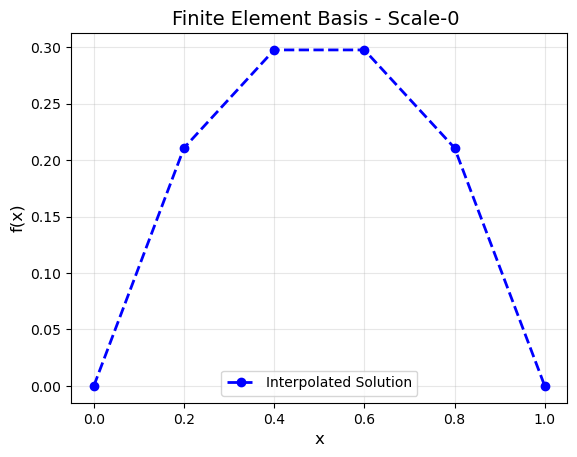

In [922]:
# Plot the interpolated solution with a dashed black line
plt.plot(x_array, C_fea, color='blue', linestyle='--', label='Interpolated Solution', 
         linewidth=2, marker='o', markersize=6, zorder=2)

# # Plot the actual solution with a solid red line
# plt.plot(x_100, exact_array_sin, color='red', linestyle='-', label='Exact Solution', 
#          linewidth=2, zorder=1)

# Add labels to the axes
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title("Finite Element Basis - Scale-0 ", fontsize=14)

# Add a legend to distinguish the two plots
plt.legend(loc='best', fontsize=10)

# Add a grid for better visualization
plt.grid(alpha=0.3)

# Show the plot
plt.show()

Wavelets

In [923]:
wavelet_scale = 3
C_wavelet = np.zeros(((2**wavelet_scale + 1)* (total_nodes-1) , 1))
x_array_wavelet = np.linspace(x_ini, x_final, (2**(wavelet_scale)) * (total_nodes - 1) + 1)

In [924]:
for i in range(total_nodes-1):
    k_wavelet = calculate_k(wavelet_scale) * (eps/element_length)    
    f_wavelet = forcing_matrix(element_length, forcing_50, wavelet_scale)
    m_wavelet = mass_matrix(element_length, wavelet_scale) * c
    bc1 = C_fea[i]
    bc2 = C_fea[i+1]
    C_element = static_solution_wavelet(2**wavelet_scale +1, k_wavelet, m_wavelet, f_wavelet, bc1, bc2)
    C_wavelet[i*(2**wavelet_scale + 1): (i+1)*(2**wavelet_scale +1)] = C_element

In [925]:
inter_sol = interpolate_solution(C_wavelet, total_nodes, x_ini, x_final, wavelet_scale, x_array_wavelet)

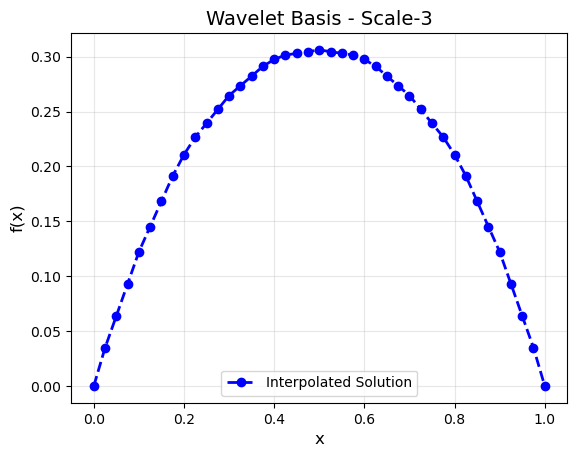

In [926]:
# Plot the interpolated solution with a dashed black line
plt.plot(x_array_wavelet, inter_sol, color='blue', linestyle='--', label='Interpolated Solution', 
         linewidth=2, marker = 'o', markersize=6, zorder=2)

# Plot the actual solution with a solid red line
# plt.plot(x_100, exact_array_sin, color='red', linestyle='-', label='Exact Solution', 
        #  linewidth=2, zorder=1)

# Add labels to the axes
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title("Wavelet Basis - Scale-3", fontsize=14)

# Add a legend to distinguish the two plots
plt.legend(loc='best', fontsize=10)

# Add a grid for better visualization
plt.grid(alpha=0.3)

# Show the plot
plt.show()